# Distributions on Spheres

The purpose of these experiments is to understand how the Observable Wasserstein Distance behaves when using pure distance-to-point functions as observables, versus functions which are minima of collections of distance-to-point functions. In particular, we wish to make empirical observations about how the observable wasserstein distance converges to the true wasserstein distance.

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import ot
import time
import itertools
import pandas as pd
import ot

Main functions for the experiment:

In [77]:
# ------------------------------------------------------------
# Sampling and spherical distance utilities
# ------------------------------------------------------------

def sample_uniform_sphere(num_points, dim, rng=None):
    """
    Sample num_points iid points uniformly from the unit sphere S^{dim-1}
    by normalizing Gaussian vectors.
    """
    if rng is None:
        rng = np.random.default_rng()

    X = rng.normal(size=(num_points, dim))
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    if np.any(norms == 0):
        raise RuntimeError("Encountered zero vector during sphere sampling.")
    return X / norms


def pairwise_spherical_distances(X, Y, assume_unit_norm=True):
    """
    Pairwise spherical/geodesic distances between rows of X and Y:
        d_S(x,y) = arccos(<x,y>)
    after normalizing if requested.
    """
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must both be 2D arrays.")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: {X.shape[1]} vs {Y.shape[1]}")

    if not assume_unit_norm:
        X_norms = np.linalg.norm(X, axis=1, keepdims=True)
        Y_norms = np.linalg.norm(Y, axis=1, keepdims=True)

        if np.any(X_norms == 0) or np.any(Y_norms == 0):
            raise ValueError("Cannot normalize zero vectors.")

        X = X / X_norms
        Y = Y / Y_norms

    G = X @ Y.T
    G = np.clip(G, -1.0, 1.0)
    return np.arccos(G)


# ------------------------------------------------------------
# Observable spherical Wasserstein distance, streaming over subsets
# ------------------------------------------------------------

def observable_spherical_wasserstein_distance_all_subsets_streaming(
    A,
    B,
    anchors,
    num_functions_in_observables,
    num_observables,
    rng=None,
    assume_unit_norm=True,
):
    """
    Observable Wasserstein-style distance on the sphere.

    For each randomly sampled anchor set S_j of size m, include all nonempty
    subset observables
        f_T(x) = min_{a in T} d_S(x, a),   T subset of S_j, T nonempty
    and return the maximum empirical 1D Wasserstein distance over all such
    observables.

    This version streams over subsets to avoid building a huge (n, L, 2^m-1)
    array in memory.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    anchors = np.asarray(anchors, dtype=float)

    if A.shape != B.shape:
        raise ValueError(f"A and B must have the same shape, got {A.shape} and {B.shape}")

    n, d = A.shape
    k, d2 = anchors.shape
    if d != d2:
        raise ValueError(f"Point dimension mismatch: {d} vs {d2}")

    m = int(num_functions_in_observables)
    L = int(num_observables)

    if not (1 <= m <= k):
        raise ValueError(
            f"Need 1 <= num_functions_in_observables <= number of anchors; got {m}, {k}"
        )
    if L < 1:
        raise ValueError("num_observables must be at least 1")

    if rng is None:
        rng = np.random.default_rng()
    elif isinstance(rng, (int, np.integer)):
        rng = np.random.default_rng(rng)

    D_A = pairwise_spherical_distances(A, anchors, assume_unit_norm=assume_unit_norm)
    D_B = pairwise_spherical_distances(B, anchors, assume_unit_norm=assume_unit_norm)

    subsets = np.array(
        [rng.choice(k, size=m, replace=False) for _ in range(L)],
        dtype=np.int64
    )  # shape (L, m)

    Dsel_A = D_A[:, subsets]   # shape (n, L, m)
    Dsel_B = D_B[:, subsets]   # shape (n, L, m)

    max_cost = -np.inf

    for r in range(1, m + 1):
        for idx_tuple in itertools.combinations(range(m), r):
            idx = np.array(idx_tuple, dtype=np.int64)

            obs_A = np.min(Dsel_A[:, :, idx], axis=2)   # (n, L)
            obs_B = np.min(Dsel_B[:, :, idx], axis=2)   # (n, L)

            obs_A.sort(axis=0)
            obs_B.sort(axis=0)

            diffs = np.abs(obs_A - obs_B)
            per_observable_costs = np.mean(diffs, axis=0)

            subset_max = np.max(per_observable_costs)
            if subset_max > max_cost:
                max_cost = subset_max

    return float(max_cost)


# ------------------------------------------------------------
# OT / EMD on the sphere
# ------------------------------------------------------------

def spherical_emd2(A, B, assume_unit_norm=True):
    """
    Compute the Earth Mover's distance between the empirical measures on A and B
    using spherical geodesic distance as the ground metric.

    Uses POT's ot.emd2 with uniform weights.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    if A.shape != B.shape:
        raise ValueError(f"A and B must have the same shape, got {A.shape} and {B.shape}")

    n = A.shape[0]
    a = np.full(n, 1.0 / n)
    b = np.full(n, 1.0 / n)

    M = pairwise_spherical_distances(A, B, assume_unit_norm=assume_unit_norm)
    return float(ot.emd2(a, b, M))


# ------------------------------------------------------------
# Main experiment
# ------------------------------------------------------------

def run_spherical_observable_experiment(
    d=3,
    n=200,
    k=200,
    n_obs_list=(20, 40, 60, 80, 100),
    n_func_list=(1, 3, 5, 7, 9),
    num_runs=10,
    base_seed=0,
):
    """
    Runs the experiment:

      - For each run:
          * sample A, B, anchors uniformly from S^{d-1}
          * compute spherical EMD once
          * for each (n_obs, n_func), compute observable spherical distance
          * record relative error = (EMD - observable_distance) / EMD
          * record timings

    Returns
    -------
    results_df : long-form pandas DataFrame with one row per run / parameter pair
    rel_error_matrix : DataFrame of average relative errors, indexed by n_func and columns n_obs
    obs_time_matrix : DataFrame of average observable-computation times
    total_pair_time_matrix : DataFrame of average pair-computation times
    ot_run_df : DataFrame with one row per run for OT timing
    """
    results = []
    ot_run_records = []

    master_rng = np.random.default_rng(base_seed)

    for run_idx in range(num_runs):
        run_seed = int(master_rng.integers(0, 2**32 - 1))
        rng = np.random.default_rng(run_seed)

        run_start = time.perf_counter()

        sample_start = time.perf_counter()
        A = sample_uniform_sphere(n, d, rng=rng)
        B = sample_uniform_sphere(n, d, rng=rng)
        anchors = sample_uniform_sphere(k, d, rng=rng)
        sample_time = time.perf_counter() - sample_start

        ot_start = time.perf_counter()
        wdist = spherical_emd2(A, B, assume_unit_norm=True)
        ot_time = time.perf_counter() - ot_start

        ot_run_records.append({
            "run": run_idx,
            "seed": run_seed,
            "sample_time_sec": sample_time,
            "ot_distance": wdist,
            "ot_time_sec": ot_time,
        })

        for n_func in n_func_list:
            for n_obs in n_obs_list:
                pair_start = time.perf_counter()

                obs_rng_seed = int(rng.integers(0, 2**32 - 1))
                obs_rng = np.random.default_rng(obs_rng_seed)

                obs_start = time.perf_counter()
                obs_dist = observable_spherical_wasserstein_distance_all_subsets_streaming(
                    A=A,
                    B=B,
                    anchors=anchors,
                    num_functions_in_observables=n_func,
                    num_observables=n_obs,
                    rng=obs_rng,
                    assume_unit_norm=True,
                )
                obs_time = time.perf_counter() - obs_start

                pair_total_time = time.perf_counter() - pair_start

                abs_error = wdist - obs_dist
                relative_error = abs_error / wdist if wdist > 0 else 0.0

                results.append({
                    "run": run_idx,
                    "seed": run_seed,
                    "observable_seed": obs_rng_seed,
                    "d": d,
                    "n": n,
                    "k": k,
                    "n_obs": n_obs,
                    "n_func": n_func,
                    "ot_distance": wdist,
                    "observable_distance": obs_dist,
                    "absolute_error": abs_error,
                    "relative_error": relative_error,
                    "sample_time_sec": sample_time,
                    "ot_time_sec": ot_time,
                    "obs_time_sec": obs_time,
                    "pair_total_time_sec": pair_total_time,
                    "num_subsets_per_observable": 2**n_func - 1,
                })

        run_total_time = time.perf_counter() - run_start
        ot_run_records[-1]["run_total_time_sec"] = run_total_time

        print(
            f"Completed run {run_idx + 1}/{num_runs} | "
            f"OT={wdist:.6f} | OT time={ot_time:.3f}s | total run time={run_total_time:.3f}s"
        )

    results_df = pd.DataFrame(results)
    ot_run_df = pd.DataFrame(ot_run_records)

    rel_error_matrix = (
        results_df.groupby(["n_func", "n_obs"])["relative_error"]
        .mean()
        .unstack("n_obs")
        .sort_index()
    )

    obs_time_matrix = (
        results_df.groupby(["n_func", "n_obs"])["obs_time_sec"]
        .mean()
        .unstack("n_obs")
        .sort_index()
    )

    total_pair_time_matrix = (
        results_df.groupby(["n_func", "n_obs"])["pair_total_time_sec"]
        .mean()
        .unstack("n_obs")
        .sort_index()
    )

    return results_df, rel_error_matrix, obs_time_matrix, total_pair_time_matrix, ot_run_df


# ------------------------------------------------------------
# Plotting helpers
# ------------------------------------------------------------

def plot_heatmap(
    matrix_df,
    title,
    xlabel="Number of observables",
    ylabel="Number of functions in observables",
    value_format="{:.3f}",
    figsize=(8, 6),
):
    """
    Plot a heatmap from a pandas DataFrame whose rows/columns are numeric.
    """
    data = matrix_df.to_numpy()

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, aspect="auto", origin="lower")

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_xticklabels(matrix_df.columns)

    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_yticklabels(matrix_df.index)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(
                j, i, value_format.format(data[i, j]),
                ha="center", va="center"
            )

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    return fig, ax

Some plotting and diagnostic functions, not used in the paper:

In [78]:
def plot_error_vs_n_obs(rel_error_matrix):
    """
    Plot average relative error vs n_obs, one curve for each n_func.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    x = rel_error_matrix.columns.to_numpy(dtype=float)

    for n_func in rel_error_matrix.index:
        y = rel_error_matrix.loc[n_func].to_numpy(dtype=float)
        ax.plot(x, y, marker='o', label=f"n_func = {n_func}")

    ax.set_xlabel("Number of observables (n_obs)")
    ax.set_ylabel("Average relative error")
    ax.set_title("Relative error vs n_obs")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    return fig, ax


def plot_error_vs_n_func(rel_error_matrix):
    """
    Plot average relative error vs n_func, one curve for each n_obs.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    x = rel_error_matrix.index.to_numpy(dtype=float)

    for n_obs in rel_error_matrix.columns:
        y = rel_error_matrix[n_obs].to_numpy(dtype=float)
        ax.plot(x, y, marker='o', label=f"n_obs = {n_obs}")

    ax.set_xlabel("Number of functions in observables (n_func)")
    ax.set_ylabel("Average relative error")
    ax.set_title("Relative error vs n_func")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    return fig, ax


def plot_error_vs_n_obs_logy(rel_error_matrix):
    """
    Same as plot_error_vs_n_obs, but with log scale on the y-axis.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    x = rel_error_matrix.columns.to_numpy(dtype=float)

    for n_func in rel_error_matrix.index:
        y = rel_error_matrix.loc[n_func].to_numpy(dtype=float)
        ax.plot(x, y, marker='o', label=f"n_func = {n_func}")

    ax.set_xlabel("Number of observables (n_obs)")
    ax.set_ylabel("Average relative error")
    ax.set_title("Relative error vs n_obs (log y-scale)")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    return fig, ax


def plot_error_vs_time(rel_error_matrix, obs_time_matrix):
    """
    Plot average relative error vs average compute time, one curve for each n_func.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    for n_func in rel_error_matrix.index:
        x = obs_time_matrix.loc[n_func].to_numpy(dtype=float)
        y = rel_error_matrix.loc[n_func].to_numpy(dtype=float)

        order = np.argsort(x)
        x = x[order]
        y = y[order]

        ax.plot(x, y, marker='o', label=f"n_func = {n_func}")

    ax.set_xlabel("Average observable compute time (seconds)")
    ax.set_ylabel("Average relative error")
    ax.set_title("Relative error vs compute time")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    return fig, ax

def estimate_loglog_slopes_n_obs(rel_error_matrix):
    """
    Estimate local slopes d log(error) / d log(n_obs) for each fixed n_func.
    Returns a DataFrame indexed by n_func, with one column per adjacent interval.
    """
    x = rel_error_matrix.columns.to_numpy(dtype=float)
    logx = np.log(x)

    slope_rows = []
    interval_labels = []

    for j in range(len(x) - 1):
        interval_labels.append(f"{int(x[j])}->{int(x[j+1])}")

    for n_func in rel_error_matrix.index:
        y = rel_error_matrix.loc[n_func].to_numpy(dtype=float)

        # Protect against zeros
        y = np.maximum(y, 1e-15)
        logy = np.log(y)

        slopes = np.diff(logy) / np.diff(logx)
        slope_rows.append(slopes)

    return pd.DataFrame(slope_rows, index=rel_error_matrix.index, columns=interval_labels)

The main plotting function

In [79]:
def plot_error_vs_time_scatter(rel_error_matrix, obs_time_matrix):
    """
    Scatter plot of error vs compute time:
      - marker shape encodes n_func
      - color encodes n_obs (discrete colorbar)
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Marker shapes for n_func
    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
    n_func_values = list(rel_error_matrix.index)
    n_obs_values = list(rel_error_matrix.columns)

    # Create a discrete colormap
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(n_obs_values)))

    # Map each n_obs to a color index
    color_map = {n_obs: colors[i] for i, n_obs in enumerate(n_obs_values)}

    for i, n_func in enumerate(n_func_values):
        marker = markers[i % len(markers)]

        for n_obs in n_obs_values:
            x = obs_time_matrix.loc[n_func, n_obs]
            y = rel_error_matrix.loc[n_func, n_obs]

            ax.scatter(
                x, y,
                marker=marker,
                color=color_map[n_obs],
                s=90,
                edgecolor='black'
            )

    # ---- Discrete colorbar ----
    from matplotlib.colors import ListedColormap, BoundaryNorm

    discrete_cmap = ListedColormap(colors)
    bounds = np.arange(len(n_obs_values) + 1)
    norm = BoundaryNorm(bounds, discrete_cmap.N)

    sm = plt.cm.ScalarMappable(cmap=discrete_cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(len(n_obs_values)) + 0.5)
    cbar.ax.set_yticklabels(n_obs_values)
    cbar.set_label("Number of observables (n_obs)")

    # ---- Legend for n_func (marker shapes) ----
    for i, n_func in enumerate(n_func_values):
        ax.scatter([], [], marker=markers[i % len(markers)],
                   color='gray', label=f"n_func = {n_func}")

    ax.legend(title="n_func", loc="best")

    ax.set_xlabel("Average observable compute time (seconds)")
    ax.set_ylabel("Average relative error")
    ax.set_title("Relative error vs compute time")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    return fig, ax

Running the main experiment:

Running dimension = 2
Running n = 100
Completed run 1/10 | OT=0.126253 | OT time=0.001s | total run time=3.299s
Completed run 2/10 | OT=0.234196 | OT time=0.002s | total run time=3.246s
Completed run 3/10 | OT=0.245805 | OT time=0.002s | total run time=3.688s
Completed run 4/10 | OT=0.130053 | OT time=0.002s | total run time=3.235s
Completed run 5/10 | OT=0.144246 | OT time=0.002s | total run time=3.337s
Completed run 6/10 | OT=0.158815 | OT time=0.002s | total run time=3.299s
Completed run 7/10 | OT=0.182446 | OT time=0.002s | total run time=3.117s
Completed run 8/10 | OT=0.157536 | OT time=0.002s | total run time=3.135s
Completed run 9/10 | OT=0.183342 | OT time=0.002s | total run time=3.125s
Completed run 10/10 | OT=0.241570 | OT time=0.008s | total run time=3.173s

Approximate local log-log slopes in n_obs:
          40->80   80->120  120->160  160->200
n_func                                        
1      -0.042621 -0.004098 -0.088925 -0.042245
3      -0.032831 -0.052980  0.025665

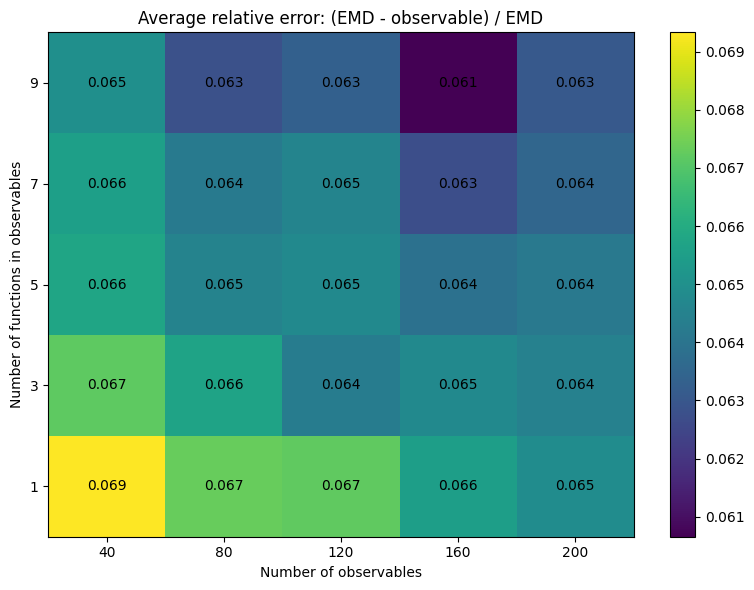

Running n = 200
Completed run 1/10 | OT=0.121326 | OT time=0.005s | total run time=6.763s
Completed run 2/10 | OT=0.130826 | OT time=0.003s | total run time=7.387s
Completed run 3/10 | OT=0.263970 | OT time=0.004s | total run time=7.943s
Completed run 4/10 | OT=0.151960 | OT time=0.004s | total run time=7.862s
Completed run 5/10 | OT=0.138786 | OT time=0.004s | total run time=7.343s
Completed run 6/10 | OT=0.116189 | OT time=0.004s | total run time=6.949s
Completed run 7/10 | OT=0.091469 | OT time=0.004s | total run time=7.026s
Completed run 8/10 | OT=0.140630 | OT time=0.004s | total run time=6.970s
Completed run 9/10 | OT=0.108220 | OT time=0.004s | total run time=7.241s
Completed run 10/10 | OT=0.094820 | OT time=0.005s | total run time=7.103s

Approximate local log-log slopes in n_obs:
          40->80   80->120  120->160  160->200
n_func                                        
1      -0.231825 -0.059109 -0.040312  0.031591
3      -0.011151 -0.036415  0.011051 -0.032846
5      -0.0

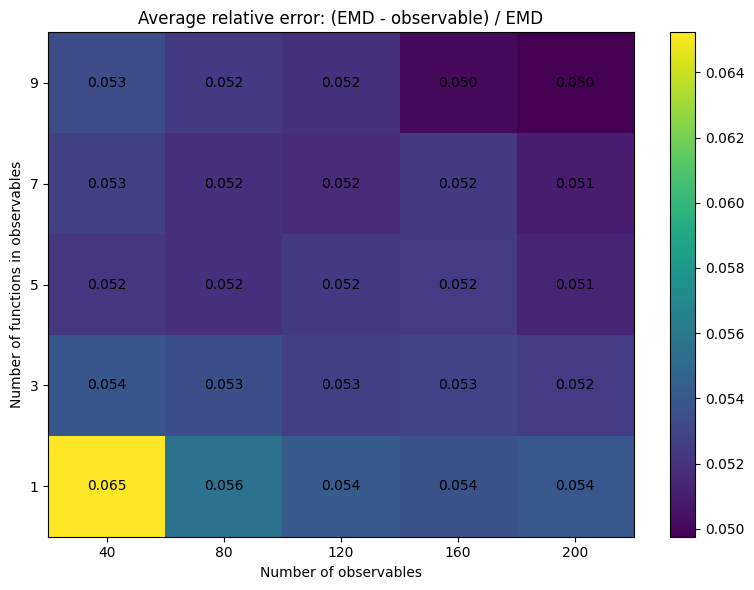

Running dimension = 3
Running n = 100
Completed run 1/10 | OT=0.258112 | OT time=0.002s | total run time=3.465s
Completed run 2/10 | OT=0.312800 | OT time=0.002s | total run time=3.283s
Completed run 3/10 | OT=0.267693 | OT time=0.002s | total run time=3.235s
Completed run 4/10 | OT=0.310454 | OT time=0.002s | total run time=3.171s
Completed run 5/10 | OT=0.243907 | OT time=0.002s | total run time=3.243s
Completed run 6/10 | OT=0.275157 | OT time=0.002s | total run time=3.160s
Completed run 7/10 | OT=0.385526 | OT time=0.002s | total run time=3.398s
Completed run 8/10 | OT=0.294287 | OT time=0.002s | total run time=3.084s
Completed run 9/10 | OT=0.231696 | OT time=0.002s | total run time=3.117s
Completed run 10/10 | OT=0.309557 | OT time=0.002s | total run time=3.373s

Approximate local log-log slopes in n_obs:
          40->80   80->120  120->160  160->200
n_func                                        
1      -0.048245  0.001874 -0.106272 -0.010201
3      -0.018862  0.022844 -0.056919

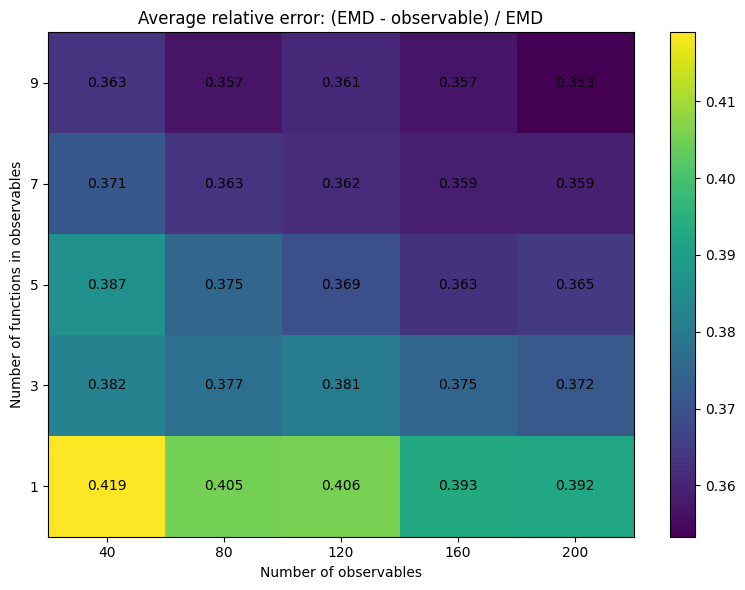

Running n = 200
Completed run 1/10 | OT=0.201411 | OT time=0.005s | total run time=7.119s
Completed run 2/10 | OT=0.191686 | OT time=0.004s | total run time=7.097s
Completed run 3/10 | OT=0.237416 | OT time=0.004s | total run time=6.613s
Completed run 4/10 | OT=0.223386 | OT time=0.004s | total run time=6.596s
Completed run 5/10 | OT=0.206973 | OT time=0.004s | total run time=6.844s
Completed run 6/10 | OT=0.213243 | OT time=0.003s | total run time=7.090s
Completed run 7/10 | OT=0.198815 | OT time=0.005s | total run time=7.034s
Completed run 8/10 | OT=0.230831 | OT time=0.004s | total run time=6.984s
Completed run 9/10 | OT=0.226716 | OT time=0.004s | total run time=6.770s
Completed run 10/10 | OT=0.211904 | OT time=0.004s | total run time=6.726s

Approximate local log-log slopes in n_obs:
          40->80   80->120  120->160  160->200
n_func                                        
1      -0.051029 -0.051382 -0.017932  0.004513
3      -0.002113 -0.048770 -0.047940  0.036603
5       0.0

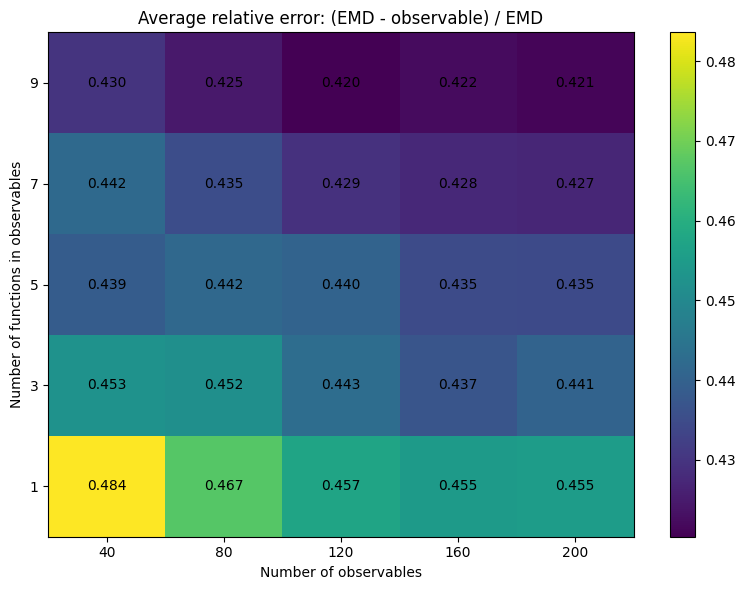

Running dimension = 4
Running n = 100
Completed run 1/10 | OT=0.446852 | OT time=0.002s | total run time=3.283s
Completed run 2/10 | OT=0.416771 | OT time=0.001s | total run time=3.259s
Completed run 3/10 | OT=0.439387 | OT time=0.001s | total run time=3.013s
Completed run 4/10 | OT=0.405599 | OT time=0.002s | total run time=3.015s
Completed run 5/10 | OT=0.421485 | OT time=0.001s | total run time=3.062s
Completed run 6/10 | OT=0.415979 | OT time=0.001s | total run time=3.032s
Completed run 7/10 | OT=0.399661 | OT time=0.001s | total run time=3.005s
Completed run 8/10 | OT=0.400746 | OT time=0.001s | total run time=2.984s
Completed run 9/10 | OT=0.403368 | OT time=0.007s | total run time=2.987s
Completed run 10/10 | OT=0.403819 | OT time=0.008s | total run time=2.989s

Approximate local log-log slopes in n_obs:
          40->80   80->120  120->160  160->200
n_func                                        
1      -0.024121 -0.037127  0.013692  0.008535
3       0.011959 -0.042012  0.029308

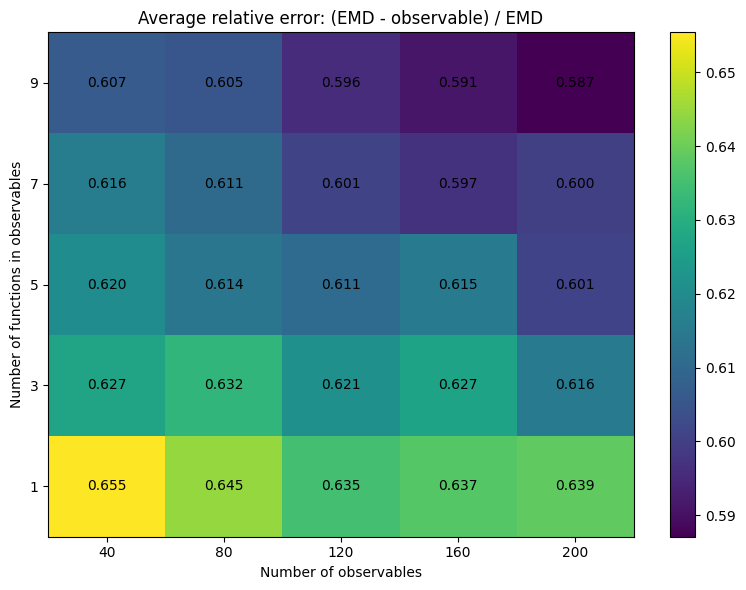

Running n = 200
Completed run 1/10 | OT=0.356969 | OT time=0.005s | total run time=6.538s
Completed run 2/10 | OT=0.333061 | OT time=0.004s | total run time=6.974s
Completed run 3/10 | OT=0.346444 | OT time=0.004s | total run time=6.823s
Completed run 4/10 | OT=0.323608 | OT time=0.003s | total run time=6.521s
Completed run 5/10 | OT=0.326988 | OT time=0.004s | total run time=6.538s
Completed run 6/10 | OT=0.329459 | OT time=0.003s | total run time=6.523s
Completed run 7/10 | OT=0.338322 | OT time=0.003s | total run time=6.527s
Completed run 8/10 | OT=0.325271 | OT time=0.003s | total run time=6.530s
Completed run 9/10 | OT=0.336227 | OT time=0.004s | total run time=6.521s
Completed run 10/10 | OT=0.315612 | OT time=0.003s | total run time=6.526s

Approximate local log-log slopes in n_obs:
          40->80   80->120  120->160  160->200
n_func                                        
1      -0.017801 -0.000628 -0.038471 -0.017398
3      -0.002433 -0.001377 -0.044353  0.033810
5      -0.0

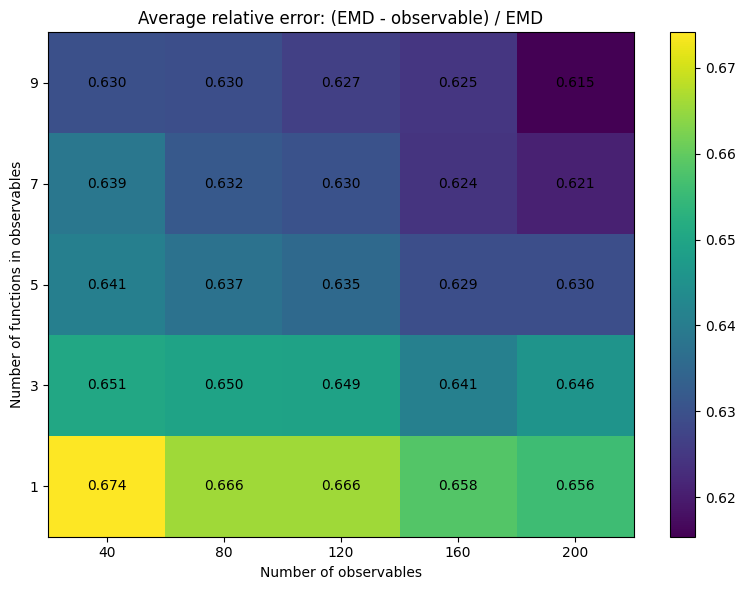

In [99]:
n_obs_list = [40,80,120,160,200]
n_func_list = [1, 3, 5, 7, 9]

dimensions = [2,3,4]
num_samples = [100,200]

all_results = {}

for d in dimensions:
    print(f'Running dimension = {d}')
    all_results[d] = {}
    for n in num_samples:
        print(f'Running n = {n}')
        all_results[d][n] = {}
        results_df, rel_error_matrix, obs_time_matrix, total_pair_time_matrix, ot_run_df = (
            run_spherical_observable_experiment(
                d=d,
                n=n,
                k=1000,
                n_obs_list=n_obs_list,
                n_func_list=n_func_list,
                num_runs=10,
                base_seed=12345,
            )
        )

        plot_heatmap(
            rel_error_matrix,
            title="Average relative error: (EMD - observable) / EMD",
            value_format="{:.3f}",
        )

        all_results[d][n]['results_df'] = results_df
        all_results[d][n]['rel_error_matrix'] = rel_error_matrix
        all_results[d][n]['obs_time_matrix'] = obs_time_matrix
        all_results[d][n]['total_pair_time_matrix'] = total_pair_time_matrix
        all_results[d][n]['ot_run_df'] = ot_run_df
        
        # plot_error_vs_n_obs(rel_error_matrix)
        # plot_error_vs_n_func(rel_error_matrix)
        # plot_error_vs_n_obs_logy(rel_error_matrix)
        # plot_error_vs_time(rel_error_matrix, obs_time_matrix)

        slope_df = estimate_loglog_slopes_n_obs(rel_error_matrix)
        print("\nApproximate local log-log slopes in n_obs:")
        print(slope_df)

        plt.show()

The main plotting functions used in the paper:

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

def plot_error_vs_time_scatter_on_ax(
    rel_error_matrix,
    obs_time_matrix,
    ax,
    n_func_values=None,
    n_obs_values=None,
    markers=None,
    colors=None,
    show_xlabel=True,
    show_ylabel=True,
    title=None,
):
    """
    Draw scatter plot of relative error vs compute time onto an existing axis.

    Encoding:
      - marker shape = n_func
      - color = n_obs
    """
    if n_func_values is None:
        n_func_values = list(rel_error_matrix.index)
    if n_obs_values is None:
        n_obs_values = list(rel_error_matrix.columns)

    if markers is None:
        markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

    if colors is None:
        cmap = plt.cm.viridis
        colors = cmap(np.linspace(0, 1, len(n_obs_values)))

    color_map = {n_obs: colors[i] for i, n_obs in enumerate(n_obs_values)}

    for i, n_func in enumerate(n_func_values):
        marker = markers[i % len(markers)]

        for n_obs in n_obs_values:
            x = obs_time_matrix.loc[n_func, n_obs]
            y = rel_error_matrix.loc[n_func, n_obs]

            ax.scatter(
                x,
                y,
                marker=marker,
                color=color_map[n_obs],
                s=70,
                edgecolor='black',
                linewidth=0.5,
            )

    if show_xlabel:
        ax.set_xlabel("Avg. compute time (s)")
    if show_ylabel:
        ax.set_ylabel("Avg. relative error")

    if title is not None:
        ax.set_title(title)

    ax.grid(alpha=0.3)

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def plot_all_error_vs_time_scatter(
    all_results,
    dimensions,
    num_samples,
    figsize=(14, 8),
):
    """
    Grid of scatter plots:
      - rows correspond to num_samples (n)
      - columns correspond to dimensions (d)

    Encoding:
      - marker shape = n_func
      - color = n_obs
    """
    example_rel = all_results[dimensions[0]][num_samples[0]]['rel_error_matrix']
    n_func_values = list(example_rel.index)
    n_obs_values = list(example_rel.columns)

    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(n_obs_values)))

    fig, axes = plt.subplots(len(num_samples), len(dimensions), figsize=figsize)
    axes = np.atleast_2d(axes)

    # ---- Plot panels ----
    for i, n in enumerate(num_samples):          # rows = n
        for j, d in enumerate(dimensions):       # columns = d
            ax = axes[i, j]

            rel_error_matrix = all_results[d][n]['rel_error_matrix']
            obs_time_matrix = all_results[d][n]['obs_time_matrix']

            for f_idx, n_func in enumerate(n_func_values):
                marker = markers[f_idx % len(markers)]

                for o_idx, n_obs in enumerate(n_obs_values):
                    x = obs_time_matrix.loc[n_func, n_obs]
                    y = rel_error_matrix.loc[n_func, n_obs]

                    ax.scatter(
                        x,
                        y,
                        marker=marker,
                        color=colors[o_idx],
                        s=70,
                        edgecolor='black',
                        linewidth=0.5,
                    )

            # Axis labels only on outer edges
            if i == len(num_samples) - 1:
                ax.set_xlabel("Avg. compute time (s)", fontsize = 12)
            if j == 0:
                ax.set_ylabel("Avg. relative error", fontsize = 12)

            ax.set_title(f"d = {d-1}, m = {n}", fontsize = 12)
            ax.grid(alpha=0.3)

    # ---- Legend: marker shapes (n_func) ----
    marker_handles = []
    for i, n_func in enumerate(n_func_values):
        handle = plt.Line2D(
            [0], [0],
            marker=markers[i % len(markers)],
            color='gray',
            linestyle='None',
            markerfacecolor='gray',
            markeredgecolor='black',
            markersize=8,
            label=f"{n_func}",
        )
        marker_handles.append(handle)

    fig.legend(
        handles=marker_handles,
        loc='upper center',
        ncol=len(n_func_values),
        bbox_to_anchor=(0.25, 1.04),
        title="Max Number of Functions in Observables",
        title_fontsize=12,
        fontsize = 12,
        frameon=True,
    )

    # ---- Legend: colors (n_obs) ----
    color_handles = []
    for i, n_obs in enumerate(n_obs_values):
        handle = Patch(
            facecolor=colors[i],
            edgecolor='black',
            label=f"{n_obs}",
        )
        color_handles.append(handle)

    fig.legend(
        handles=color_handles,
        loc='upper center',
        ncol=len(n_obs_values),
        bbox_to_anchor=(0.75, 1.04),
        title="Number of Observables",
        title_fontsize=12,
        fontsize = 12,
        frameon=True,
    )

    # ---- Layout ----
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    return fig, axes

Plot for the paper:

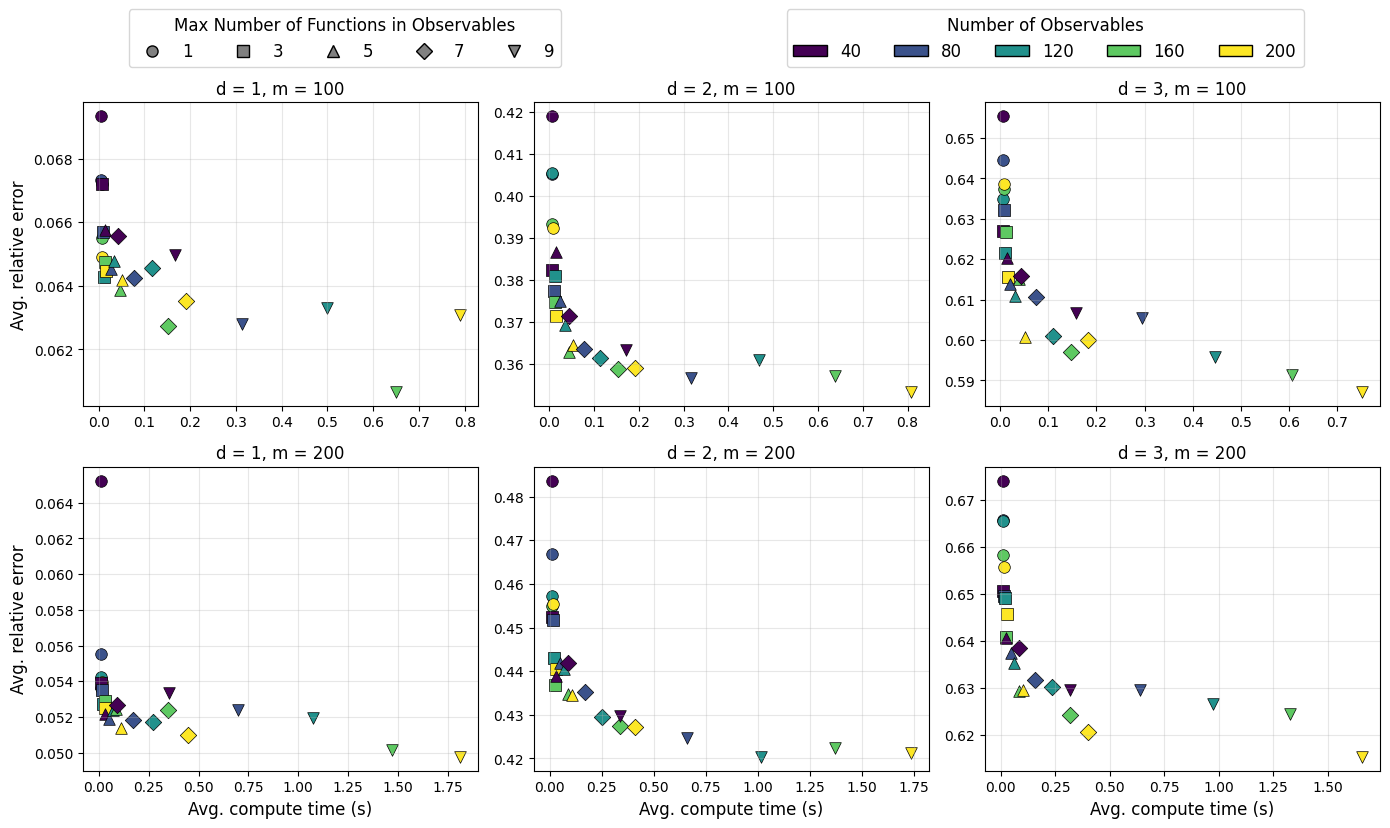

In [139]:
fig, axes = plot_all_error_vs_time_scatter(
    all_results=all_results,
    dimensions=dimensions,
    num_samples=num_samples,
    figsize=(14, 8),
)

plt.savefig('sphereExperiment.png',bbox_inches='tight',dpi=300)
plt.show()